# Titanic Survival Prediction

## Business Problem

The sinking of the RMS Titanic is one of the most famous maritime disasters in history.

The objective of this project is to build a machine learning model capable of predicting whether a passenger survived the disaster based on passenger information such as age, gender, ticket class, fare, and family relationships.

This project demonstrates the complete Data Science workflow:

- Business Understanding
- Data Collection
- Exploratory Data Analysis (EDA)
- Data Cleaning
- Feature Engineering
- Model Building
- Model Evaluation
- Business Insights

## Data Collection

In [310]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Display Plots inside notebook
%matplotlib inline


In [210]:
# Import the dataset into a DataFrame

train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

In [211]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Exploratory Data Analysis

Exploratory Data Analysis (EDA) helps us understand the structure of the dataset, identify missing values, detect patterns and uncover relationships between variables before building machine learning models.

##### - Dataset Information

Let us get the basic summary the dataset.

In [212]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [213]:
# Get a summary of the dataset, including count, mean, std, min, 25%, 50%, 75%, and max values for each column

train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [214]:
# Getting the number of missing values in each column

train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [216]:
# Percentage of missing values in each column

missing_percentage = (train_df.isnull().sum()/len(train_df))* 100
round(missing_percentage).sort_values(ascending=False)


Cabin          77.0
Age            20.0
PassengerId     0.0
Survived        0.0
Name            0.0
Pclass          0.0
SibSp           0.0
Sex             0.0
Parch           0.0
Ticket          0.0
Fare            0.0
Embarked        0.0
dtype: float64

Insight:

The dataset has **916** rows and **12** columns showing the passenger details and survival of each passenger.

##### - Survival Rate

Here, we'll be exploring the survival rate of specific measures like `Age`, `Gender` etc to get an insight on variables affecting passengers survival.

In [219]:
# Survival Count

train_df['Survived'].value_counts()


Survived
0    549
1    342
Name: count, dtype: int64

In [220]:
# Survival Distribution

round(train_df['Survived'].value_counts(normalize = True)*100)


Survived
0    62.0
1    38.0
Name: proportion, dtype: float64

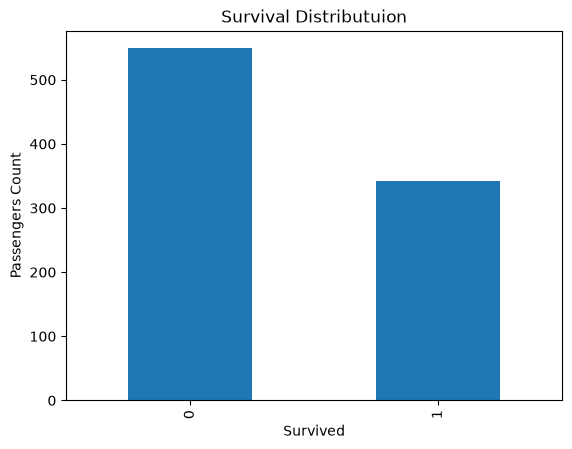

In [221]:
# Survival Distribution Chart

train_df['Survived'].value_counts().plot(kind='bar')

plt.title('Survival Distributuion')
plt.xlabel('Survived')
plt.ylabel('Passengers Count')

plt.show()



Insight:

Only 38% of the passengers on board survived the Ship accident.

##### - Survival by Passenger Gender

In [223]:
# Get the number of survivors and non-survivors by gender

pd.crosstab(train_df['Sex'], train_df['Survived'])

Survived,0,1
Sex,,
female,81,233
male,468,109


In [228]:
# 

round(pd.crosstab(
    train_df['Sex'], 
    train_df['Survived'],
    normalize='index')*100,1)


Survived,0,1
Sex,,
female,25.8,74.2
male,81.1,18.9


In [ ]:
# Survival by Gender

gender_survival = pd.crosstab(
    train_df['Sex'], 
    train_df['Survived'],
    normalize='index'
)

gender_survival.plot(kind='bar')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')

plt.show()

Insight:

Female passengers had a significntly higher survival rate than male passengers, with approximately 74% of females surviving.

74% of the female passengers survived and 81% of the male passengers did not survive.

##### - Survival by Passenger Gender

In [231]:
# Survival by Age Group

train_df['Age_Group'] = np.where(
    train_df['Age'] < 18, 'Child',
    'Adult'
)

pd.crosstab(train_df['Age_Group'],
            train_df['Survived'],
            normalize='index')

Survived,0,1
Age_Group,,
Adult,0.638817,0.361183
Child,0.460177,0.539823


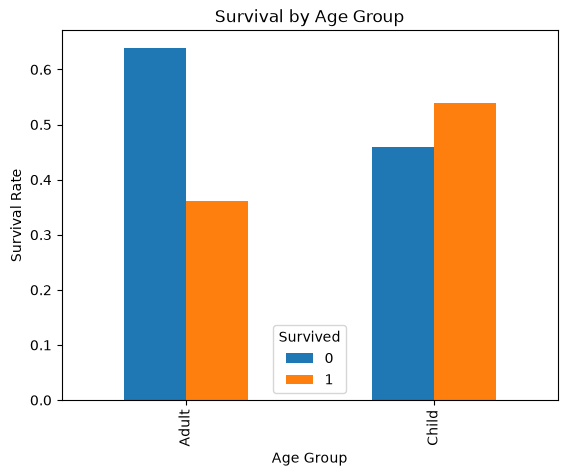

In [304]:
# Survival by Age Group

survival_by_age = pd.crosstab(
    train_df['Age_Group'],
    train_df['Survived'],
    normalize='index'
)

survival_by_age.plot(kind='bar')
plt.title('Survival by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.savefig("../images/survival_by_age.png", dpi=300)

plt.show()


Insight:

Children had higher survival rate compared to adults. Although, only 53% of the children survived.

##### Survival by Passenger Class

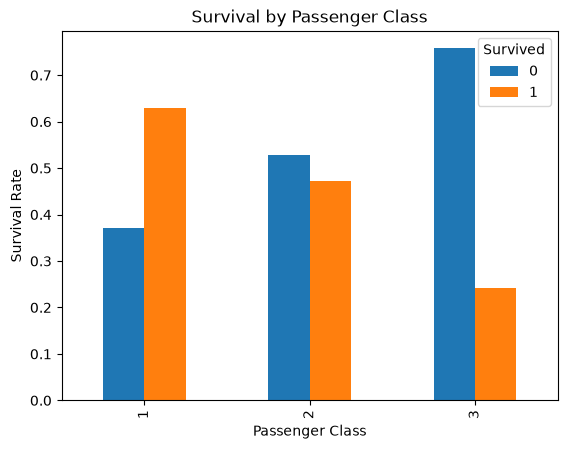

In [303]:
# Survival by Passenger Class

class_survival = pd.crosstab(
    train_df['Pclass'], 
    train_df['Survived'],
    normalize ='index'
)

class_survival.plot(kind = 'bar')
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.savefig("../images/class_survival.png", dpi=300)
plt.show()

Passengers in First Class had the highest survival rate. Cabin class also played a significant role in the chances of survival.
Passengers in lower classes had lower survival rate. 62% of passengers in the First Class cabin survived.

## Data Cleaning and Feature Enngineering

Raw data often doesn't contain the best predictors directly. In this section, new features such as Family Size, Is Alone, and Passenger Title are created to improve model performance.

##### Data Cleaning

In [234]:
train_df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
Survived         0
PassengerId      0
Sex              0
Name             0
Pclass           0
SibSp            0
Ticket           0
Parch            0
Fare             0
Age_Group        0
dtype: int64

In [235]:
# Make a copy of the data

clean_df =train_df.copy()

In [236]:
# Drop the 'Cabin' and 'PassengerId' columns due to a high number of missing values

clean_df.drop(columns=['Cabin','PassengerId'],inplace=True)

In [237]:
# Fill missing age values with median age

clean_df['Age'] = clean_df['Age'].fillna(clean_df['Age'].median(),inplace=True)


C:\Users\AUTOCHECK\AppData\Local\Temp\ipykernel_7408\1127932770.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  clean_df['Age'] = clean_df['Age'].fillna(clean_df['Age'].median(),inplace=True)


In [238]:
# Fill the missing values for the 'Embarked' column using the mode since it is a categorical variable.

clean_df['Embarked'] = clean_df['Embarked'].fillna(clean_df['Embarked'].mode()[0])

In [239]:
# Check the cleaned dataset.

clean_df.isnull().sum()

Survived     0
Pclass       0
Name         0
Sex          0
Age          0
SibSp        0
Parch        0
Ticket       0
Fare         0
Embarked     0
Age_Group    0
dtype: int64

Data Cleaning Summary

- The `Cabin` column was dropped due to the high percentage of empty values (approximately 77%).
- The `PassengerId` column was also dropped due to the fact it serves as a unique identifier in our data and it does not contribute to the prediction of passenger's survival.
- Missing values in `Age` was imputed using median, while missing values in `Embarked` was filled using the most frequent record in the field.

After preprocessing the data, the data no longer have missing values in its features and it is ready for feature engineering.

##### Feature Engineering

In [240]:
# Family Size Feature

clean_df['Family_Size'] = clean_df['SibSp']  + clean_df['Parch'] +1

In [241]:
# Is Passenger Alone Feature

clean_df['Is_Alone'] = np.where(clean_df['Family_Size'] >1,0,1)

In [242]:
# Passenger Title Feature

clean_df['Title'] = clean_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

In [243]:
# Age Group Feature

clean_df['Age_Group'] = np.where(clean_df['Age'] < 18, 'Child', 'Adult')

In [244]:
# Survival Rate by Family Size

pd.crosstab(
    clean_df['Family_Size'],
    clean_df['Survived'],
    normalize='index'
)*100

Survived,0,1
Family_Size,,
1,69.646182,30.353818
2,44.720497,55.279503
3,42.156863,57.843137
4,27.586207,72.413793
5,80.000000,20.000000
6,86.363636,13.636364
7,66.666667,33.333333
8,100.000000,0.000000
11,100.000000,0.000000


In [245]:
# Survival Rate by Title

pd.crosstab(
    clean_df['Title'],
    clean_df['Survived'],
    normalize='index',
)*100

Survived,0,1
Title,,
Capt,100.000000,0.000000
Col,50.000000,50.000000
Countess,0.000000,100.000000
Don,100.000000,0.000000
Dr,57.142857,42.857143
Jonkheer,100.000000,0.000000
Lady,0.000000,100.000000
Major,50.000000,50.000000
Master,42.500000,57.500000


Feature Engineering Insights

- Passengers traveling with family had a higher survival rate than those traveling alone.
- Family presence may have provided support during evacuation.
- The `Title` feature was informative, with `Mrs` having one of the highest survival rates.
- Extracting titles from names adds valuable information that was not directly available in the original dataset.

## Model Building and Evaluation

To explore and identify the best model for this exercise, I'll be working with Logistic Regression, Decision Tree Classifier and Random Forest Classifier.

In [246]:
# Display the cleaned dataset information
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Name         891 non-null    str    
 3   Sex          891 non-null    str    
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    str    
 8   Fare         891 non-null    float64
 9   Embarked     891 non-null    str    
 10  Age_Group    891 non-null    str    
 11  Family_Size  891 non-null    int64  
 12  Is_Alone     891 non-null    int64  
 13  Title        891 non-null    str    
dtypes: float64(2), int64(6), str(6)
memory usage: 97.6 KB


In [247]:
# Drop the 'Name' and 'Ticket' columns since they are not useful for prediction.

model_df = clean_df.drop(columns=['Name','Ticket'])

In [248]:
model_df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'Age_Group', 'Family_Size', 'Is_Alone', 'Title'],
      dtype='str')

In [ ]:
# For data modeling, we need to encode categorical columns.

model_df.select_dtypes(include=['object']).columns

C:\Users\AUTOCHECK\AppData\Local\Temp\ipykernel_7408\567407577.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  model_df.select_dtypes(include=['object']).columns


Index(['Sex', 'Embarked', 'Age_Group', 'Title'], dtype='str')

In [252]:
# DataFrame with encoded categorical columns for modeling. We will use one-hot encoding to convert categorical variables into numerical format.

model_df = pd.get_dummies(
    model_df,
    drop_first=True
)

In [251]:
model_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Family_Size,Is_Alone,Sex_male,Embarked_Q,...,Title_Major,Title_Master,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir
0,0,3,22.0,1,0,7.2500,2,0,True,False,...,False,False,False,False,False,True,False,False,False,False
1,1,1,38.0,1,0,71.2833,2,0,False,False,...,False,False,False,False,False,False,True,False,False,False
2,1,3,26.0,0,0,7.9250,1,1,False,False,...,False,False,True,False,False,False,False,False,False,False
3,1,1,35.0,1,0,53.1000,2,0,False,False,...,False,False,False,False,False,False,True,False,False,False
4,0,3,35.0,0,0,8.0500,1,1,True,False,...,False,False,False,False,False,True,False,False,False,False


##### Feature Selection

In [253]:
# Feature Selection

X = model_df.drop(columns=['Survived'])
y = model_df['Survived']

In [254]:
# Split Dataset into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=42)

##### Build Logistic Model

In [257]:
# Instantiate the models

log_model = LogisticRegression(max_iter=1000)

In [258]:
# Fit Model

log_model.fit(X_train,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [271]:
# Predict Model

log_pred = log_model.predict(X_test)

In [272]:
# Evaluate the model's accuracy using the accuracy_score function from sklearn.metrics.

log_accuracy = accuracy_score(y_test,log_pred)

print(f'Accuracy Score: {log_accuracy:.4f}')

Accuracy Score: 0.8101


In [284]:
log_result = classification_report(y_test, log_pred)
print(log_result)

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       105
           1       0.77      0.77      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [309]:
joblib.dump(log_model, "../models/logistic_regression_model.pkl")

['../models/logistic_regression_model.pkl']

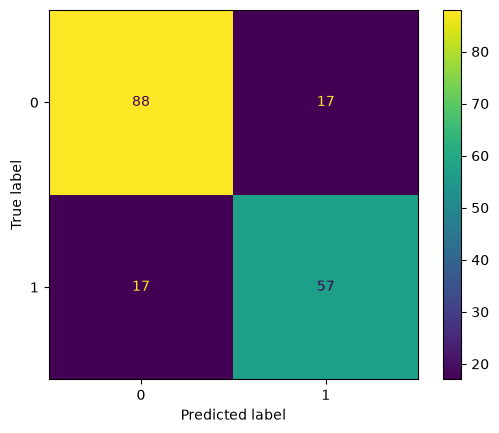

In [275]:
# Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    log_pred
)

plt.show()

Logistic Regression Results

- The Logistic Regression model achieved an accuracy of **81%** on the test dataset.

- The model correctly classified most passengers, with a precision and recall of **77%** for the "Survived" class.

- The confusion matrix shows that the model made **34 incorrect predictions** out of **179** test samples, indicating good overall performance.

Overall, Logistic Regression provides a strong baseline model due to its simplicity, interpretability, and competitive performance.

##### Decision Tree Model

In [276]:
# Instantiate the Decision Tree Classifier model.
dt_model = DecisionTreeClassifier(random_state=42)

# Fit the Decision Tree Model
dt_model.fit(X_train, y_train)

# Predict using Decision Tree Model
dt_pred =  dt_model.predict(X_test)

# Evaluate the Decision Tree Model
dt_accuracy =accuracy_score(y_test,dt_pred)

dt_accuracy

0.7653631284916201

In [283]:
dt_result = classification_report(y_test, dt_pred)
print(dt_result)

              precision    recall  f1-score   support

           0       0.81      0.79      0.80       105
           1       0.71      0.73      0.72        74

    accuracy                           0.77       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179



In [308]:
joblib.dump(dt_model, "../models/decision_tree_model.pkl")

['../models/decision_tree_model.pkl']

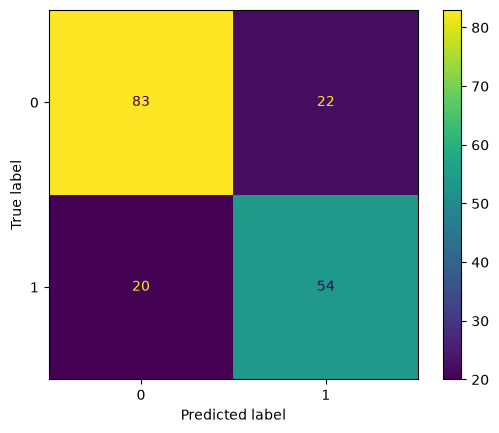

In [277]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred
)

plt.show()

##### Random Forest Classifier

In [279]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [280]:
accuracy_score(y_test, rf_pred)

0.8324022346368715

In [286]:
rf_result = classification_report(y_test, rf_pred)

print(rf_result)

              precision    recall  f1-score   support

           0       0.86      0.86      0.86       105
           1       0.80      0.80      0.80        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179



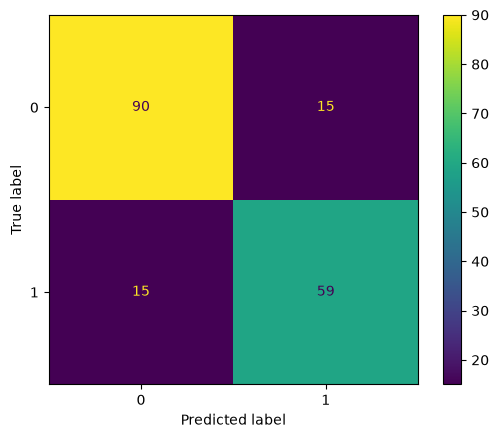

In [311]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)
plt.savefig("../images/confusion_matrix_Random_Forest.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

plt.show()

In [ ]:
joblib.dump(rf_model, "../models/random_forest_model.pkl")

['../models/random_forest_model.pkl']

##### Compare all three models

In [295]:
def evaluate_model(model_name,y_true, predictions):
    """
    Evaluate the classification model's performance
    
    Parameters:
    model_name : The name of the model being evaluated
    y_true : Actual target values
    predictions : Predicted target values
    
    Returns:
    A dictionary containing the model's name, accuracy, precision, recall and F1 score.
    """

    return {
        "Model": model_name,
        "Accuracy" : accuracy_score(y_true,predictions),
        "Precision": precision_score(y_true,predictions),
        "Recall": recall_score(y_true,predictions),
        "F1": f1_score(y_true,predictions)
    }

In [294]:
# Logistic Regression Evaluation
log_results =evaluate_model("Logistic Regression",y_test,log_pred)

# Decision Tree Evaluation
dt_results = evaluate_model("Decision Tree", y_test,dt_pred)

#Random Forest Evaluation
rf_results = evaluate_model("Random Forest",y_test,rf_pred)

In [297]:
# Convert the results into a DataFrame for better visualization.

results = pd.DataFrame([log_results, dt_results, rf_results])

round(results, 4)

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.8101,0.7703,0.7703,0.7703
1,Decision Tree,0.7654,0.7105,0.7297,0.7200
2,Random Forest,0.8324,0.7973,0.7973,0.7973


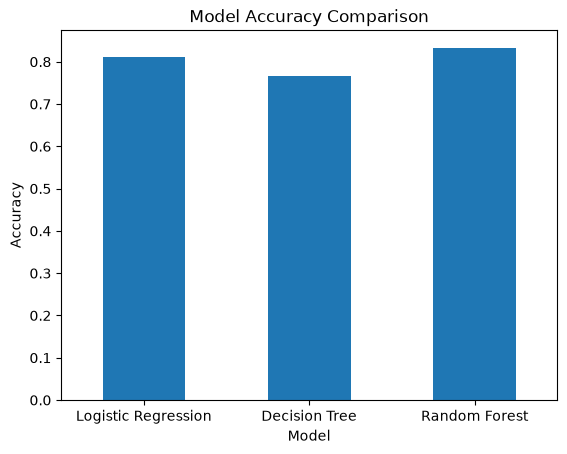

In [305]:
results.set_index("Model")["Accuracy"].plot(kind="bar")

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.savefig("../images/model_comparison_results.png", dpi=300)

plt.show()

## Conclusion

##### Model Comparison Result

Three machine learning models were trained and evaluated to predict passenger survival.

| Model | Accuracy |
|--------|---------:|
| Logistic Regression | **81.01%** |
| Decision Tree | **76.54%** |
| Random Forest | **83.24%** |

Among the three models, the **Random Forest Classifier** achieved the highest accuracy, precision, recall, and F1-score.

The improved performance is likely due to Random Forest's ensemble learning approach, which combines multiple decision trees to reduce overfitting and improve generalization.

Although Logistic Regression performed competitively and offers better interpretability, Random Forest was selected as the final model because it provided the best predictive performance on the test dataset.

## Feature Importance

In [312]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
4,Fare,0.236720
1,Age,0.205575
22,Title_Mr,0.123735
7,Sex_male,0.119403
0,Pclass,0.074891
5,Family_Size,0.046784
23,Title_Mrs,0.037951
19,Title_Miss,0.032005
2,SibSp,0.030031
3,Parch,0.021252


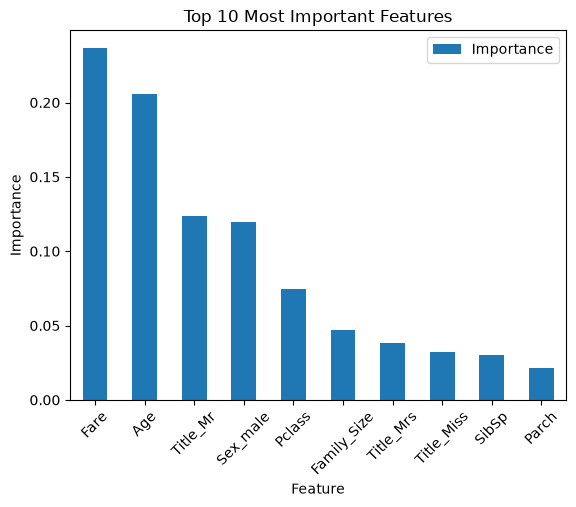

In [313]:
feature_importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Top 10 Most Important Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)

plt.savefig(
    "../images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()